# Detección de Vehículos con Cascade Mask R-CNN + Swin Transformer

**Univ.:** Joel Galvan  
**Modelo:** Cascade Mask R-CNN con backbone Swin-T (2023-2024) — Modelo de **2 etapas**  
**Dataset:** vehicle-detection-by9xs (Roboflow) — Formato JSON COCO  
**Framework:** MMDetection  
**División del dataset:** 70% train / 15% val / 15% test  

---

> ⚠️ **Nota importante:** El dataset `vehicle-detection-by9xs` descargado localmente desde Roboflow
> contiene **únicamente la carpeta `train/`** con sus anotaciones en formato JSON COCO.
> Este notebook realiza automáticamente la división en conjuntos de validación y test
> antes del entrenamiento.

---

## Contexto del Modelo

**Cascade Mask R-CNN** es un detector de **dos etapas**:
- **Etapa 1 (Region Proposal Network - RPN):** Propone regiones candidatas de interés (RoIs)
- **Etapa 2 (Cascade R-CNN heads):** Clasifica y refina las bounding boxes con múltiples umbrales IoU en cascada (0.5 → 0.6 → 0.7), además de generar máscaras de segmentación de instancias

El backbone **Swin Transformer** (publicado en ICCV 2021, con versiones y checkpoints actualizados hasta 2024) reemplaza a ResNet como extractor de características, usando atención local con ventanas desplazadas (*shifted windows*).

**Referencia:** Liu et al., *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows*, ICCV 2021. Checkpoints pre-entrenados en COCO disponibles en MMDetection Model Zoo (2023-2024).

## Celda 1 — Instalación de dependencias

Ejecutar una sola vez. Requiere CUDA instalado en el sistema.

In [ ]:
# ─── Instalación de MMDetection y dependencias ────────────────────────────────
# Verifica la versión de CUDA antes de instalar
import subprocess
result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'CUDA no encontrado — revisa tu instalación')

# Instalar openmim para gestión de paquetes OpenMMLab
!pip install -U openmim -q

# Instalar MMEngine y MMCV (versiones compatibles con MMDetection 3.x)
!mim install mmengine -q
!mim install "mmcv>=2.0.0" -q

# Instalar MMDetection 3.x (compatible con Cascade Mask R-CNN + Swin, 2023-2024)
!mim install "mmdet>=3.0.0" -q

# Dependencias adicionales
!pip install pycocotools scikit-learn matplotlib Pillow tqdm -q

print('\n✅ Instalación completada.')

## Celda 2 — Importaciones y verificación del entorno

In [1]:
import os
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch

# Verificaciones del entorno
print('=== Verificación del entorno ===')
print(f'PyTorch:  {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

import mmdet
import mmcv
import mmengine
print(f'\nMMDet:    {mmdet.__version__}')
print(f'MMCV:     {mmcv.__version__}')
print(f'MMEngine: {mmengine.__version__}')
print('\n✅ Entorno listo.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\luisc\.conda\envs\openmmlab\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start

=== Verificación del entorno ===
PyTorch:  2.1.0+cu121
CUDA disponible: True
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.3 GB

MMDet:    3.3.0
MMCV:     2.1.0
MMEngine: 0.10.7

✅ Entorno listo.


## Celda 3 — Configuración de rutas del dataset

Ajusta `DATASET_ROOT` a la ruta local donde descargaste el dataset de Roboflow.

In [2]:
# ─── CONFIGURACIÓN DE RUTAS ───────────────────────────────────────────────────
# Modifica esta ruta según donde tengas el dataset descargado
DATASET_ROOT = Path('./dataset')  # <-- Cambiar si es necesario

# Rutas del dataset original (solo contiene 'train')
TRAIN_ORIGINAL_DIR   = DATASET_ROOT / 'train'
TRAIN_IMAGES_DIR     = TRAIN_ORIGINAL_DIR  # Las imágenes están dentro de train/
TRAIN_ANNOTATIONS    = TRAIN_ORIGINAL_DIR / '_annotations.coco.json'  # JSON COCO de Roboflow

# Directorio donde se guardarán los splits
SPLIT_DIR = DATASET_ROOT / 'splits'
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for sub in ['train', 'val', 'test']:
    (SPLIT_DIR / sub / 'images').mkdir(parents=True, exist_ok=True)

# Proporciones de división
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Verificación de que el dataset existe
assert TRAIN_ORIGINAL_DIR.exists(), f'❌ No se encontró el directorio: {TRAIN_ORIGINAL_DIR}'
assert TRAIN_ANNOTATIONS.exists(), f'❌ No se encontró el archivo de anotaciones: {TRAIN_ANNOTATIONS}'

print(f'Dataset root:   {DATASET_ROOT.resolve()}')
print(f'Anotaciones:    {TRAIN_ANNOTATIONS}')
print(f'División:       {int(TRAIN_RATIO*100)}% train / {int(VAL_RATIO*100)}% val / {int(TEST_RATIO*100)}% test')
print('✅ Rutas configuradas correctamente.')

Dataset root:   C:\Users\luisc\OneDrive\Documents\SeptimoSemestre\IA2026\La6\dataset
Anotaciones:    dataset\train\_annotations.coco.json
División:       70% train / 15% val / 15% test
✅ Rutas configuradas correctamente.


## Celda 4 — Exploración del dataset original

In [3]:
# Cargar anotaciones COCO
with open(TRAIN_ANNOTATIONS, 'r') as f:
    coco_data = json.load(f)

images      = coco_data['images']
annotations = coco_data['annotations']
categories  = coco_data['categories']

print('=== Estadísticas del Dataset Original ===')
print(f'Total de imágenes:     {len(images)}')
print(f'Total de anotaciones:  {len(annotations)}')
print(f'Número de categorías:  {len(categories)}')
print(f'\nCategorías:')
for cat in categories:
    count = sum(1 for ann in annotations if ann['category_id'] == cat['id'])
    print(f'  [{cat["id"]}] {cat["name"]}: {count} instancias')

# Verificar imágenes en disco
img_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
img_files = [f for f in TRAIN_IMAGES_DIR.iterdir()
             if f.suffix.lower() in img_extensions]
print(f'\nArchivos de imagen en disco: {len(img_files)}')

=== Estadísticas del Dataset Original ===
Total de imágenes:     9211
Total de anotaciones:  58324
Número de categorías:  7

Categorías:
  [0] vehicles: 0 instancias
  [1] bus: 6681 instancias
  [2] car: 27293 instancias
  [3] microbus: 3574 instancias
  [4] motorbike: 14971 instancias
  [5] pickup-van: 4246 instancias
  [6] truck: 1559 instancias

Archivos de imagen en disco: 9211


## Celda 5 — División del dataset (70% / 15% / 15%)

Como el dataset de Roboflow solo tiene `train/`, se realiza la división manualmente
respetando el formato JSON COCO para cada subset.

In [4]:
def split_coco_dataset(coco_data, train_ratio, val_ratio, test_ratio, seed=42):
    """Divide un dataset COCO en train/val/test manteniendo el formato."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, 'Las proporciones deben sumar 1.0'

    all_images = coco_data['images'].copy()
    random.seed(seed)
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_imgs = all_images[:n_train]
    val_imgs   = all_images[n_train:n_train + n_val]
    test_imgs  = all_images[n_train + n_val:]

    def build_split(img_list):
        img_ids = {img['id'] for img in img_list}
        split_anns = [ann for ann in coco_data['annotations']
                      if ann['image_id'] in img_ids]
        return {
            'info':        coco_data.get('info', {}),
            'licenses':    coco_data.get('licenses', []),
            'categories':  coco_data['categories'],
            'images':      img_list,
            'annotations': split_anns
        }

    return build_split(train_imgs), build_split(val_imgs), build_split(test_imgs)


def copy_images(img_list, src_dir, dst_dir):
    """Copia las imágenes del split a su carpeta destino."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    missing = 0
    for img in tqdm(img_list, desc=f'Copiando a {dst_dir.parent.name}/'):
        src = src_dir / img['file_name']
        dst = dst_dir / img['file_name']
        if src.exists():
            shutil.copy2(src, dst)
        else:
            missing += 1
    if missing:
        print(f'  ⚠️  {missing} imágenes no encontradas en disco.')


# Ejecutar la división
print('Dividiendo dataset...')
train_coco, val_coco, test_coco = split_coco_dataset(
    coco_data, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, seed=RANDOM_SEED
)

# Guardar JSONs
splits = {'train': train_coco, 'val': val_coco, 'test': test_coco}
for name, data in splits.items():
    json_path = SPLIT_DIR / name / f'_annotations.coco.json'
    with open(json_path, 'w') as f:
        json.dump(data, f)
    print(f'[{name}] {len(data["images"]):>4} imágenes | {len(data["annotations"]):>5} anotaciones → {json_path}')

# Copiar imágenes
print('\nCopiando imágenes...')
copy_images(train_coco['images'], TRAIN_IMAGES_DIR, SPLIT_DIR / 'train' / 'images')
copy_images(val_coco['images'],   TRAIN_IMAGES_DIR, SPLIT_DIR / 'val'   / 'images')
copy_images(test_coco['images'],  TRAIN_IMAGES_DIR, SPLIT_DIR / 'test'  / 'images')

print('\n✅ División completada.')

Dividiendo dataset...
[train] 6447 imágenes | 40672 anotaciones → dataset\splits\train\_annotations.coco.json
[val] 1381 imágenes |  8857 anotaciones → dataset\splits\val\_annotations.coco.json
[test] 1383 imágenes |  8795 anotaciones → dataset\splits\test\_annotations.coco.json

Copiando imágenes...


Copiando a train/:   7%|▋         | 444/6447 [00:03<00:45, 132.55it/s]


KeyboardInterrupt: 

## Celda 6 — Visualización del dataset (muestras con bounding boxes)

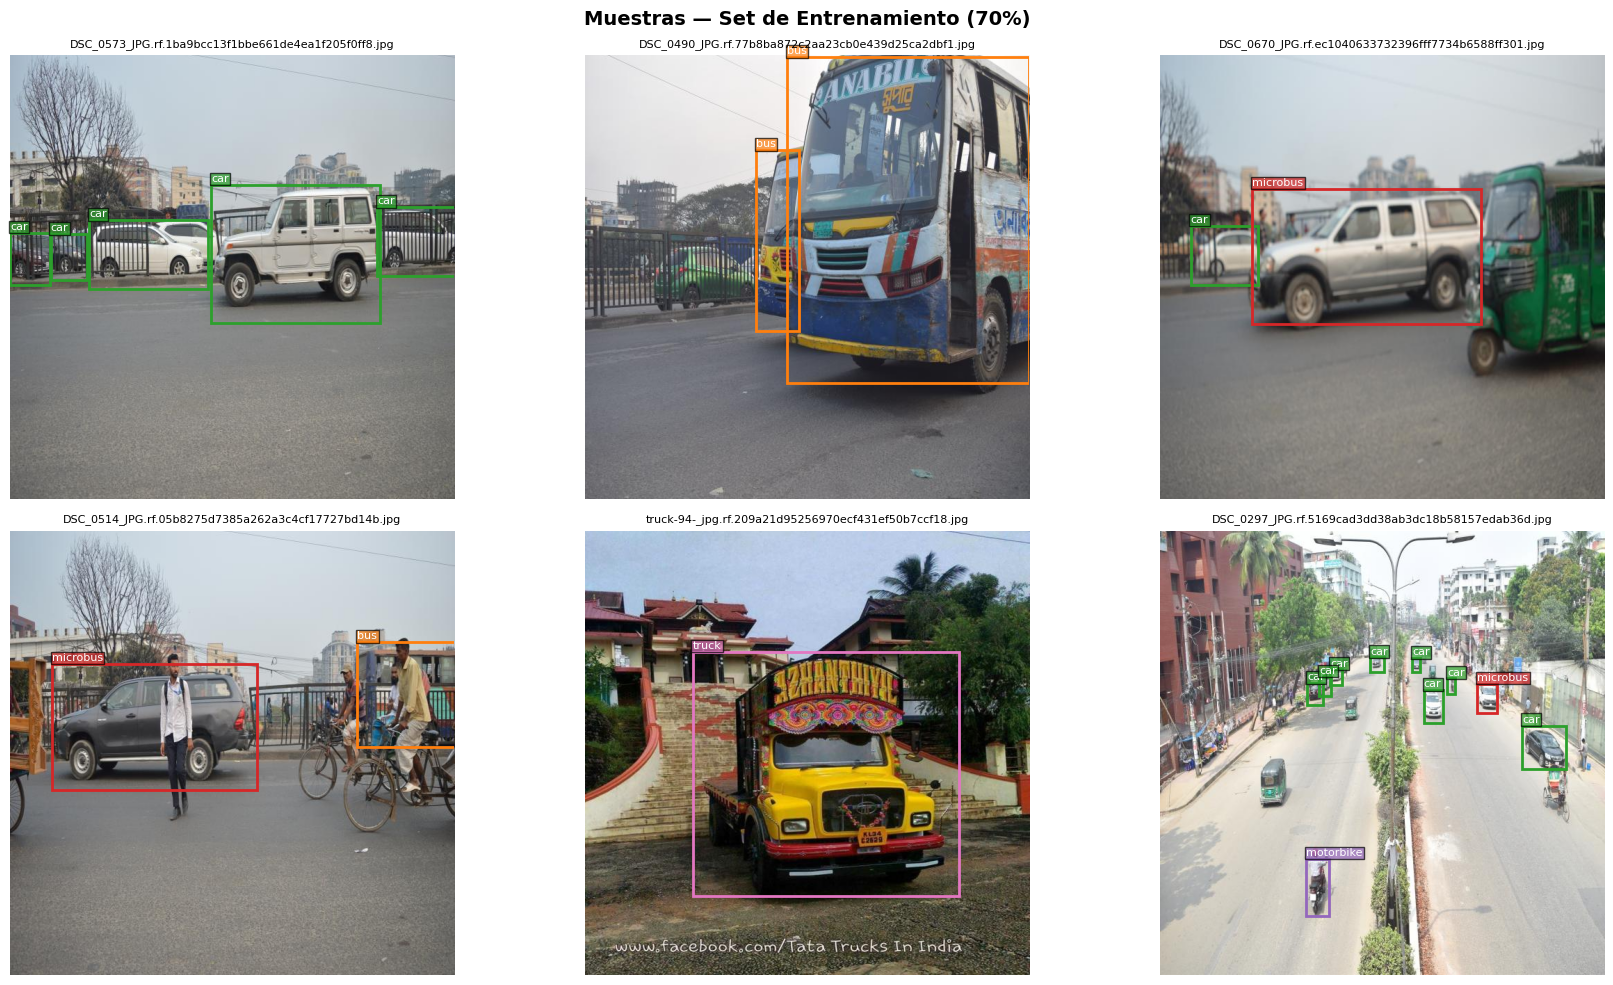

In [4]:
def visualize_coco_samples(coco_json_path, images_dir, n_samples=6, title='Muestras del dataset'):
    with open(coco_json_path) as f:
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}
    ann_by_img = {}
    for ann in data['annotations']:
        ann_by_img.setdefault(ann['image_id'], []).append(ann)

    samples = random.sample(data['images'], min(n_samples, len(data['images'])))
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()

    colors = plt.cm.tab10.colors
    cat_colors = {cid: colors[i % len(colors)] for i, cid in enumerate(cat_map)}

    for ax, img_info in zip(axes, samples):
        img_path = images_dir / img_info['file_name']
        if not img_path.exists():
            ax.set_visible(False)
            continue
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        for ann in ann_by_img.get(img_info['id'], []):
            x, y, w, h = ann['bbox']
            color = cat_colors.get(ann['category_id'], 'red')
            rect = patches.Rectangle((x, y), w, h,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 4, cat_map.get(ann['category_id'], '?'),
                    color='white', fontsize=8,
                    bbox=dict(facecolor=color, alpha=0.7, pad=1))
        ax.set_title(img_info['file_name'], fontsize=8)
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Mostrar muestras del set de entrenamiento
visualize_coco_samples(
    SPLIT_DIR / 'train' / '_annotations.coco.json',
    SPLIT_DIR / 'train' / 'images',
    n_samples=6,
    title='Muestras — Set de Entrenamiento (70%)'
)

## Celda 7 — Registro del dataset en MMDetection

In [5]:
from mmdet.registry import DATASETS
from mmdet.datasets import CocoDataset

# Obtener nombres de categorías desde el JSON
CATEGORY_NAMES = tuple(cat['name'] for cat in sorted(categories, key=lambda c: c['id']))
print(f'Categorías registradas: {CATEGORY_NAMES}')

# Registrar dataset personalizado de vehículos
@DATASETS.register_module()
class VehicleDataset(CocoDataset):
    """Dataset de vehículos (vehicle-detection-by9xs, Roboflow)."""
    METAINFO = {
        'classes': CATEGORY_NAMES,
        'palette': [(220, 20, 60), (0, 128, 0), (0, 0, 255),
                    (255, 165, 0), (128, 0, 128), (0, 255, 255),
                    (255, 255, 0), (255, 0, 255)]
    }

print('✅ VehicleDataset registrado en MMDetection.')

Categorías registradas: ('vehicles', 'bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck')
✅ VehicleDataset registrado en MMDetection.


## Celda 8 — Configuración del modelo Cascade Mask R-CNN + Swin-T

Usamos el checkpoint pre-entrenado en COCO de MMDetection Model Zoo (2023-2024).

In [14]:
from mmengine.config import Config
from mmdet.utils import register_all_modules

register_all_modules()

# ─── Rutas absolutas (barras forward para Windows) ───────────────────────────
SPLIT_ABS     = SPLIT_DIR.resolve()
SPLIT_ABS_STR = str(SPLIT_ABS).replace('\\', '/')
WORK_DIR      = Path('./work_dirs/cascade_mask_rcnn_swin_vehicles')
WORK_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR_STR  = str(WORK_DIR.resolve()).replace('\\', '/')
NUM_CLASSES   = len(CATEGORY_NAMES)

PRETRAINED_CHECKPOINT = (
    'https://download.openmmlab.com/mmdetection/v2.0/'
    'cascade_rcnn/cascade_mask_rcnn_swin-t-p4-w7_fpn_fp16_'
    'ms-crop-3x_coco/cascade_mask_rcnn_swin-t-p4-w7_fpn_'
    'fp16_ms-crop-3x_coco_20210906_143452-15e9ec5e.pth'
)

# ─── Guardar config como archivo .py con rutas ya resueltas ──────────────────
CFG_PATH = WORK_DIR / 'cascade_mask_rcnn_swin_vehicles.py'

cfg_lines = f"""
default_scope = 'mmdet'

model = dict(
    type='CascadeMaskRCNN',
    data_preprocessor=dict(
        type='DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_mask=True,
        pad_size_divisor=32),
    backbone=dict(
        type='SwinTransformer',
        embed_dims=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4,
        qkv_bias=True,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.2,
        patch_norm=True,
        out_indices=(0, 1, 2, 3),
        with_cp=False,
        convert_weights=True,
        init_cfg=dict(
            type='Pretrained',
            checkpoint='{PRETRAINED_CHECKPOINT}')),
    neck=dict(
        type='FPN',
        in_channels=[96, 192, 384, 768],
        out_channels=256,
        num_outs=5),
    rpn_head=dict(
        type='RPNHead',
        in_channels=256,
        feat_channels=256,
        anchor_generator=dict(
            type='AnchorGenerator',
            scales=[8],
            ratios=[0.5, 1.0, 2.0],
            strides=[4, 8, 16, 32, 64]),
        bbox_coder=dict(
            type='DeltaXYWHBBoxCoder',
            target_means=[0.0, 0.0, 0.0, 0.0],
            target_stds=[1.0, 1.0, 1.0, 1.0]),
        loss_cls=dict(type='CrossEntropyLoss', use_sigmoid=True, loss_weight=1.0),
        loss_bbox=dict(type='L1Loss', loss_weight=1.0)),
    roi_head=dict(
        type='CascadeRoIHead',
        num_stages=3,
        stage_loss_weights=[1, 0.5, 0.25],
        bbox_roi_extractor=dict(
            type='SingleRoIExtractor',
            roi_layer=dict(type='RoIAlign', output_size=7, sampling_ratio=0),
            out_channels=256,
            featmap_strides=[4, 8, 16, 32]),
        bbox_head=[
            dict(
                type='Shared2FCBBoxHead',
                in_channels=256, fc_out_channels=1024,
                roi_feat_size=7, num_classes={NUM_CLASSES},
                bbox_coder=dict(
                    type='DeltaXYWHBBoxCoder',
                    target_means=[0.0, 0.0, 0.0, 0.0],
                    target_stds=[0.1, 0.1, 0.2, 0.2]),
                reg_class_agnostic=True,
                loss_cls=dict(type='CrossEntropyLoss', use_sigmoid=False, loss_weight=1.0),
                loss_bbox=dict(type='SmoothL1Loss', beta=1.0, loss_weight=1.0)),
            dict(
                type='Shared2FCBBoxHead',
                in_channels=256, fc_out_channels=1024,
                roi_feat_size=7, num_classes={NUM_CLASSES},
                bbox_coder=dict(
                    type='DeltaXYWHBBoxCoder',
                    target_means=[0.0, 0.0, 0.0, 0.0],
                    target_stds=[0.05, 0.05, 0.1, 0.1]),
                reg_class_agnostic=True,
                loss_cls=dict(type='CrossEntropyLoss', use_sigmoid=False, loss_weight=1.0),
                loss_bbox=dict(type='SmoothL1Loss', beta=1.0, loss_weight=1.0)),
            dict(
                type='Shared2FCBBoxHead',
                in_channels=256, fc_out_channels=1024,
                roi_feat_size=7, num_classes={NUM_CLASSES},
                bbox_coder=dict(
                    type='DeltaXYWHBBoxCoder',
                    target_means=[0.0, 0.0, 0.0, 0.0],
                    target_stds=[0.033, 0.033, 0.067, 0.067]),
                reg_class_agnostic=True,
                loss_cls=dict(type='CrossEntropyLoss', use_sigmoid=False, loss_weight=1.0),
                loss_bbox=dict(type='SmoothL1Loss', beta=1.0, loss_weight=1.0))
        ],
        mask_roi_extractor=dict(
            type='SingleRoIExtractor',
            roi_layer=dict(type='RoIAlign', output_size=14, sampling_ratio=0),
            out_channels=256,
            featmap_strides=[4, 8, 16, 32]),
        mask_head=dict(
            type='FCNMaskHead',
            num_convs=4, in_channels=256, conv_out_channels=256,
            num_classes={NUM_CLASSES},
            loss_mask=dict(type='CrossEntropyLoss', use_mask=True, loss_weight=1.0))),
    train_cfg=dict(
        rpn=dict(
            assigner=dict(type='MaxIoUAssigner', pos_iou_thr=0.7, neg_iou_thr=0.3,
                          min_pos_iou=0.3, match_low_quality=True, ignore_iof_thr=-1),
            sampler=dict(type='RandomSampler', num=256, pos_fraction=0.5,
                         neg_pos_ub=-1, add_gt_as_proposals=False),
            allowed_border=-1, pos_weight=-1, debug=False),
        rpn_proposal=dict(
            nms_pre=2000, max_per_img=1000,
            nms=dict(type='nms', iou_threshold=0.7), min_bbox_size=0),
        rcnn=[
            dict(
                assigner=dict(type='MaxIoUAssigner', pos_iou_thr=0.5, neg_iou_thr=0.5,
                              min_pos_iou=0.5, match_low_quality=False, ignore_iof_thr=-1),
                sampler=dict(type='RandomSampler', num=512, pos_fraction=0.25,
                             neg_pos_ub=-1, add_gt_as_proposals=True),
                mask_size=28, pos_weight=-1, debug=False),
            dict(
                assigner=dict(type='MaxIoUAssigner', pos_iou_thr=0.6, neg_iou_thr=0.6,
                              min_pos_iou=0.6, match_low_quality=False, ignore_iof_thr=-1),
                sampler=dict(type='RandomSampler', num=512, pos_fraction=0.25,
                             neg_pos_ub=-1, add_gt_as_proposals=True),
                mask_size=28, pos_weight=-1, debug=False),
            dict(
                assigner=dict(type='MaxIoUAssigner', pos_iou_thr=0.7, neg_iou_thr=0.7,
                              min_pos_iou=0.7, match_low_quality=False, ignore_iof_thr=-1),
                sampler=dict(type='RandomSampler', num=512, pos_fraction=0.25,
                             neg_pos_ub=-1, add_gt_as_proposals=True),
                mask_size=28, pos_weight=-1, debug=False)
        ]),
    test_cfg=dict(
        rpn=dict(nms_pre=1000, max_per_img=1000,
                 nms=dict(type='nms', iou_threshold=0.7), min_bbox_size=0),
        rcnn=dict(score_thr=0.05, nms=dict(type='nms', iou_threshold=0.5),
                  max_per_img=100, mask_thr_binary=0.5)))

train_pipeline = [
    dict(type='LoadImageFromFile', backend_args=None),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='RandomResize', scale=[(1333, 480), (1333, 960)], keep_ratio=True),
    dict(type='RandomFlip', prob=0.5),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile', backend_args=None),
    dict(type='Resize', scale=(1333, 800), keep_ratio=True),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='PackDetInputs',
         meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

train_dataloader = dict(
    batch_size=2,
    num_workers=2,
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    batch_sampler=dict(type='AspectRatioBatchSampler'),
    dataset=dict(
        type='VehicleDataset',
        data_root='{SPLIT_ABS_STR}/train/',
        ann_file='_annotations.coco.json',
        data_prefix=dict(img='images/'),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline))

val_dataloader = dict(
    batch_size=1,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type='VehicleDataset',
        data_root='{SPLIT_ABS_STR}/val/',
        ann_file='_annotations.coco.json',
        data_prefix=dict(img='images/'),
        test_mode=True,
        pipeline=test_pipeline))

test_dataloader = dict(
    batch_size=1,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type='VehicleDataset',
        data_root='{SPLIT_ABS_STR}/test/',
        ann_file='_annotations.coco.json',
        data_prefix=dict(img='images/'),
        test_mode=True,
        pipeline=test_pipeline))

val_evaluator = dict(
    type='CocoMetric',
    ann_file='{SPLIT_ABS_STR}/val/_annotations.coco.json',
    metric=['bbox', 'segm'],
    format_only=False)

test_evaluator = dict(
    type='CocoMetric',
    ann_file='{SPLIT_ABS_STR}/test/_annotations.coco.json',
    metric=['bbox', 'segm'],
    format_only=False)

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=12, val_interval=1)
val_cfg   = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

param_scheduler = [
    dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=500),
    dict(type='MultiStepLR', begin=0, end=12, by_epoch=True,
         milestones=[8, 11], gamma=0.1)
]

optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(type='AdamW', lr=0.0001, betas=(0.9, 0.999), weight_decay=0.05),
    clip_grad=dict(max_norm=1, norm_type=2),
    paramwise_cfg=dict(
        custom_keys={{
            'absolute_pos_embed': dict(decay_mult=0.0),
            'relative_position_bias_table': dict(decay_mult=0.0),
            'norm': dict(decay_mult=0.0)
        }}))

default_hooks = dict(
    timer=dict(type='IterTimerHook'),
    logger=dict(type='LoggerHook', interval=50),
    param_scheduler=dict(type='ParamSchedulerHook'),
    checkpoint=dict(type='CheckpointHook', interval=1,
                    save_best='coco/bbox_mAP', rule='greater'),
    sampler_seed=dict(type='DistSamplerSeedHook'),
    visualization=dict(type='DetVisualizationHook'))

env_cfg = dict(
    cudnn_benchmark=False,
    mp_cfg=dict(mp_start_method='fork', opencv_num_threads=0),
    dist_cfg=dict(backend='nccl'))

vis_backends = [dict(type='LocalVisBackend')]
visualizer = dict(
    type='DetLocalVisualizer',
    vis_backends=vis_backends,
    name='visualizer')

log_processor = dict(type='LogProcessor', window_size=50, by_epoch=True)
log_level = 'INFO'
load_from = None
resume = False
work_dir = '{WORK_DIR_STR}'
"""

# Guardar el archivo de configuración
with open(CFG_PATH, 'w', encoding='utf-8') as f:
    f.write(cfg_lines)

print(f'✅ Configuración guardada en: {CFG_PATH}')
print(f'   SPLIT_ABS_STR: {SPLIT_ABS_STR}')
print(f'   NUM_CLASSES:   {NUM_CLASSES}')

✅ Configuración guardada en: work_dirs\cascade_mask_rcnn_swin_vehicles\cascade_mask_rcnn_swin_vehicles.py
   SPLIT_ABS_STR: C:/Users/luisc/OneDrive/Documents/SeptimoSemestre/IA2026/La6/dataset/splits
   NUM_CLASSES:   7


In [6]:
import subprocess
from pathlib import Path

WORK_DIR = Path('./work_dirss/cascade_mask_rcnn_convnext_vehicles')
WORK_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_ABS_STR = str(SPLIT_DIR.resolve()).replace('\\', '/')
NUM_CLASSES = len(CATEGORY_NAMES)
CFG_PATH = WORK_DIR / 'cascade_mask_rcnn_convnext_vehicles.py'

# Descargar config oficial
result = subprocess.run([
    'mim', 'download', 'mmdet',
    '--config', 'cascade-mask-rcnn_convnext-t-p4-w7_fpn_4conv1fc-giou_amp-ms-crop-3x_coco',
    '--dest', str(WORK_DIR)
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr)

base_cfgs = list(WORK_DIR.glob('cascade*convnext*.py'))
print(f'Configs encontrados: {base_cfgs}')

processing cascade-mask-rcnn_convnext-t-p4-w7_fpn_4conv1fc-giou_amp-ms-crop-3x_coco...
downloading --------------------------------------- 0.0/327.9 MiB ? eta -:--:--
downloading --------------------------------------- 0.0/327.9 MiB ? eta -:--:--
downloading --------------------------------------- 0.0/327.9 MiB ? eta -:--:--
downloading --------------------------------------- 0.0/327.9 MiB ? eta -:--:--
downloading ------------------------------- 0.0/327.9 MiB 87.6 kB/s eta 1:05:25
downloading ------------------------------ 0.0/327.9 MiB 116.0 kB/s eta 0:49:24
downloading ------------------------------ 0.0/327.9 MiB 116.0 kB/s eta 0:49:24
downloading ------------------------------ 0.0/327.9 MiB 116.0 kB/s eta 0:49:24
downloading ------------------------------ 0.0/327.9 MiB 140.3 kB/s eta 0:40:51
downloading ------------------------------ 0.1/327.9 MiB 183.8 kB/s eta 0:31:11
downloading ------------------------------ 0.1/327.9 MiB 203.8 kB/s eta 0:28:07
downloading ---------------------

## Celda 9 — Cargar configuración y verificar modelo

In [29]:
import subprocess
result = subprocess.run(['mim', 'install', 'mmpretrain'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Looking in links: https://download.openmmlab.com/mmcv/dist/cpu/torch2.1.0/index.html
Ignoring mmcv: markers 'extra == "mim"' don't match your environment
Ignoring mmengine: markers 'extra == "mim"' don't match your environment
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 1.9 MB/s eta 0:00:01
   ------------------- -------------------- 0.8/1.6 MB 2.1 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.9 MB/s  0:00:00

   ------------- -------------------------- 2/6 [einops]
   ------------- -------------------------- 2/6 [einops]
   --------------------------------- ------ 5/6 [mmpretrain]
   --------------------------------- ------ 5/6 [mmpretrain]
   --------------------------------- ------ 5/6 [mmpretrain]
   ---------------------------------

In [7]:
base_cfg_path = list(WORK_DIR.glob('cascade*convnext*.py'))[0]
print(f'Usando config base: {base_cfg_path}')

with open(base_cfg_path, 'r') as f:
    base_content = f.read()

print('Config base cargado correctamente.')
print(base_content[:500])

Usando config base: work_dirss\cascade_mask_rcnn_convnext_vehicles\cascade-mask-rcnn_convnext-t-p4-w7_fpn_4conv1fc-giou_amp-ms-crop-3x_coco.py
Config base cargado correctamente.
auto_scale_lr = dict(base_batch_size=16, enable=False)
backend_args = None
checkpoint_file = 'https://download.openmmlab.com/mmclassification/v0/convnext/downstream/convnext-tiny_3rdparty_32xb128-noema_in1k_20220301-795e9634.pth'
custom_imports = dict(
    allow_failed_imports=False, imports=[
        'mmpretrain.models',
    ])
data_root = 'data/coco/'
dataset_type = 'CocoDataset'
default_hooks = dict(
    checkpoint=dict(interval=1, type='CheckpointHook'),
    logger=dict(interval=50, type='Lo


In [8]:
import json
import random
from pathlib import Path

random.seed(42)

def reducir_dataset_por_clase(json_path, max_por_clase=100):
    with open(json_path) as f:
        data = json.load(f)
    
    # Agrupar imágenes por clase
    img_por_clase = {}
    ann_by_img = {}
    for ann in data['annotations']:
        ann_by_img.setdefault(ann['image_id'], []).append(ann)
    
    for img in data['images']:
        img_id = img['id']
        clases = set(a['category_id'] for a in ann_by_img.get(img_id, []))
        for cat_id in clases:
            img_por_clase.setdefault(cat_id, []).append(img)
    
    # Seleccionar máximo 100 imágenes por clase
    imgs_seleccionadas = {}
    for cat_id, imgs in img_por_clase.items():
        random.shuffle(imgs)
        for img in imgs[:max_por_clase]:
            imgs_seleccionadas[img['id']] = img
    
    imgs_final = list(imgs_seleccionadas.values())
    ids_final  = {img['id'] for img in imgs_final}
    anns_final = [a for a in data['annotations'] if a['image_id'] in ids_final]
    
    return {
        'info':        data.get('info', {}),
        'licenses':    data.get('licenses', []),
        'categories':  data['categories'],
        'images':      imgs_final,
        'annotations': anns_final
    }

# Aplicar solo al split de train (val y test se dejan completos)
train_json = Path(SPLIT_ABS_STR) / 'train' / '_annotations.coco.json'
data_reducida = reducir_dataset_por_clase(train_json, max_por_clase=100)

# Guardar el JSON reducido
train_reducido_json = Path(SPLIT_ABS_STR) / 'train' / '_annotations_small.coco.json'
with open(train_reducido_json, 'w') as f:
    json.dump(data_reducida, f)

print(f'Dataset original:  {len(json.load(open(train_json))["images"])} imágenes')
print(f'Dataset reducido:  {len(data_reducida["images"])} imágenes')
print(f'Anotaciones:       {len(data_reducida["annotations"])}')
print(f'Guardado en:       {train_reducido_json}')

Dataset original:  6447 imágenes
Dataset reducido:  572 imágenes
Anotaciones:       4403
Guardado en:       C:\Users\luisc\OneDrive\Documents\SeptimoSemestre\IA2026\La6\dataset\splits\train\_annotations_small.coco.json


## Celda 10 — Entrenamiento

Esta celda lanza el entrenamiento completo. El modelo guarda checkpoints automáticamente
en `work_dirs/` y selecciona el mejor según `bbox_mAP` en validación.

In [1]:
import torch
import subprocess

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
print(f'CUDA version (PyTorch): {torch.version.cuda}')

# Ver si la GPU existe en el sistema
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\nnvidia-smi:')
print(result.stdout if result.returncode == 0 else 'nvidia-smi no encontrado')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\luisc\.conda\envs\openmmlab\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\luisc\.conda\envs\openmmlab\lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start

PyTorch version: 2.1.0+cpu
CUDA disponible: False
CUDA version (PyTorch): None

nvidia-smi:
Mon May 18 05:44:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P8              1W /   50W |      83MiB /   4096MiB |      0%      Default |
|                                         |     

In [ ]:
from mmengine.config import Config
from mmengine.runner import Runner
from mmdet.utils import register_all_modules
import os

register_all_modules(init_default_scope=True)

# ── Corregir rutas ────────────────────────────────────────────────────────────
WORK_DIR = Path('./work_dirss/cascade_mask_rcnn_convnext_vehicles')
WORK_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR_STR = str(WORK_DIR.resolve()).replace('\\', '/')

base_cfg_path = list(WORK_DIR.glob('cascade*convnext*.py'))[0]
cfg = Config.fromfile(str(base_cfg_path))

# Forzar work_dir correcto
cfg.work_dir = WORK_DIR_STR

# ── Adaptar al dataset de vehículos ──────────────────────────────────────────
for head in cfg.model.roi_head.bbox_head:
    head.num_classes = NUM_CLASSES
cfg.model.roi_head.mask_head.num_classes = NUM_CLASSES

cfg.train_dataloader.dataset.type        = 'VehicleDataset'
cfg.train_dataloader.dataset.data_root   = f'{SPLIT_ABS_STR}/train/'
cfg.train_dataloader.dataset.ann_file = '_annotations_small.coco.json'
cfg.train_dataloader.dataset.data_prefix = dict(img='images/')

cfg.val_dataloader.dataset.type          = 'VehicleDataset'
cfg.val_dataloader.dataset.data_root     = f'{SPLIT_ABS_STR}/val/'
cfg.val_dataloader.dataset.ann_file      = '_annotations.coco.json'
cfg.val_dataloader.dataset.data_prefix   = dict(img='images/')

cfg.test_dataloader.dataset.type         = 'VehicleDataset'
cfg.test_dataloader.dataset.data_root    = f'{SPLIT_ABS_STR}/test/'
cfg.test_dataloader.dataset.ann_file     = '_annotations.coco.json'
cfg.test_dataloader.dataset.data_prefix  = dict(img='images/')

cfg.val_evaluator.ann_file  = f'{SPLIT_ABS_STR}/val/_annotations.coco.json'
cfg.test_evaluator.ann_file = f'{SPLIT_ABS_STR}/test/_annotations.coco.json'

cfg.train_cfg.max_epochs         = 12
cfg.train_dataloader.batch_size  = 1
cfg.train_dataloader.num_workers = 1
cfg.val_dataloader.num_workers   = 2

cfg.default_hooks.checkpoint = dict(
    type='CheckpointHook',
    interval=1,
    save_best='coco/bbox_mAP',
    rule='greater'
)

# Deshabilitar AMP (precisión mixta) y usar optimizador normal
cfg.optim_wrapper.type = 'OptimWrapper'
if 'loss_scale' in cfg.optim_wrapper:
    del cfg.optim_wrapper['loss_scale']
    
    
print('=== Resumen de la configuración ===')
print(f'Modelo:     {cfg.model.type}')
print(f'Backbone:   {cfg.model.backbone.type}')
print(f'Clases:     {NUM_CLASSES}')
print(f'Épocas:     {cfg.train_cfg.max_epochs}')
print(f'Work dir:   {cfg.work_dir}')
print('\n🚀 Iniciando entrenamiento...')
print('-' * 60)
    
print(f'GPU disponible: {torch.cuda.is_available()}')
print(f'Optimizador:    {cfg.optim_wrapper.type}')

runner = Runner.from_cfg(cfg)
runner.train()

=== Resumen de la configuración ===
Modelo:     CascadeRCNN
Backbone:   mmpretrain.ConvNeXt
Clases:     7
Épocas:     12
Work dir:   C:/Users/luisc/OneDrive/Documents/SeptimoSemestre/IA2026/La6/work_dirss/cascade_mask_rcnn_convnext_vehicles

🚀 Iniciando entrenamiento...
------------------------------------------------------------
GPU disponible: True
Optimizador:    OptimWrapper
05/18 06:23:06 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1952926171
    GPU 0: NVIDIA GeForce GTX 1650
    CUDA_HOME: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: n/a
    PyTorch: 2.1.0+cu121
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MS

c:\Users\luisc\.conda\envs\openmmlab\lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


05/18 06:23:20 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
05/18 06:23:20 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

## Celda 11 — Evaluación sobre el set de TEST

Evalúa el mejor checkpoint guardado sobre el conjunto de test independiente (15%).

In [ ]:
from mmengine.runner import Runner
import glob

# Buscar el mejor checkpoint
best_ckpts = sorted(glob.glob(str(WORK_DIR / 'best_coco_bbox_mAP_epoch_*.pth')))
if not best_ckpts:
    best_ckpts = sorted(glob.glob(str(WORK_DIR / '*.pth')))

assert best_ckpts, '❌ No se encontró ningún checkpoint. Verifica que el entrenamiento terminó.'
best_checkpoint = best_ckpts[-1]
print(f'Checkpoint seleccionado: {best_checkpoint}')

# Configuración para test
cfg_test = cfg.copy()
cfg_test.load_from = best_checkpoint

runner_test = Runner.from_cfg(cfg_test)

print('\n🔍 Evaluando sobre set de TEST...')
metrics = runner_test.test()

print('\n=== Resultados finales en TEST ===')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')

## Celda 12 — Inferencia y visualización de predicciones

In [ ]:
from mmdet.apis import init_detector, inference_detector
from mmdet.visualization import DetLocalVisualizer
import mmcv

# Inicializar modelo para inferencia
model_infer = init_detector(
    str(CFG_PATH),
    best_checkpoint,
    device='cuda:0' if torch.cuda.is_available() else 'cpu'
)

# Tomar algunas imágenes de test para visualizar
test_images = list((SPLIT_DIR / 'test' / 'images').glob('*.jpg'))[:6]
if not test_images:
    test_images = list((SPLIT_DIR / 'test' / 'images').glob('*.png'))[:6]

assert test_images, '❌ No se encontraron imágenes en el set de test.'

# Visualización
cols = 3
rows = (len(test_images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

cat_palette = {i: plt.cm.tab10.colors[i % 10] for i in range(NUM_CLASSES)}

for ax, img_path in zip(axes, test_images):
    result = inference_detector(model_infer, str(img_path))
    img = mmcv.imread(str(img_path), channel_order='rgb')

    pred_instances = result.pred_instances
    scores  = pred_instances.scores.cpu().numpy()
    labels  = pred_instances.labels.cpu().numpy()
    bboxes  = pred_instances.bboxes.cpu().numpy()

    ax.imshow(img)
    for score, label, bbox in zip(scores, labels, bboxes):
        if score < 0.4:
            continue
        x1, y1, x2, y2 = bbox
        color = cat_palette.get(label, (1, 0, 0))
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        cls_name = CATEGORY_NAMES[label] if label < len(CATEGORY_NAMES) else str(label)
        ax.text(x1, y1 - 4, f'{cls_name} {score:.2f}',
                color='white', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.75, pad=1))

    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

for ax in axes[len(test_images):]:
    ax.set_visible(False)

fig.suptitle('Predicciones — Cascade Mask R-CNN + Swin-T (umbral: 0.4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Celda 13 — Curvas de entrenamiento (pérdida y mAP)

Parsea los logs generados por MMDetection para graficar el progreso del entrenamiento.

In [ ]:
import json as json_lib

# Buscar el archivo de log JSON de MMDetection
log_files = sorted(WORK_DIR.glob('*/vis_data/scalars.json'))
if not log_files:
    log_files = sorted(WORK_DIR.glob('**/*.json'))

if not log_files:
    print('⚠️ No se encontraron logs de entrenamiento. Ejecuta el entrenamiento primero.')
else:
    log_path = log_files[0]
    print(f'Leyendo log: {log_path}')

    train_loss, val_map = [], []
    with open(log_path) as f:
        for line in f:
            try:
                entry = json_lib.loads(line.strip())
                if 'loss' in entry:
                    train_loss.append(entry)
                if 'coco/bbox_mAP' in entry:
                    val_map.append(entry)
            except json_lib.JSONDecodeError:
                pass

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if train_loss:
        steps = [e.get('step', i) for i, e in enumerate(train_loss)]
        losses = [e['loss'] for e in train_loss]
        ax1.plot(steps, losses, color='steelblue', linewidth=1.5)
        ax1.set_title('Pérdida de entrenamiento')
        ax1.set_xlabel('Iteración')
        ax1.set_ylabel('Loss total')
        ax1.grid(True, alpha=0.3)

    if val_map:
        epochs = list(range(1, len(val_map) + 1))
        maps   = [e['coco/bbox_mAP'] for e in val_map]
        ax2.plot(epochs, maps, color='darkorange', marker='o', linewidth=2)
        ax2.set_title('mAP (bbox) en Validación')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('COCO bbox mAP')
        ax2.grid(True, alpha=0.3)

    fig.suptitle('Curvas de entrenamiento — Cascade Mask R-CNN + Swin-T', fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## Resumen del pipeline

| Paso | Descripción |
|------|-------------|
| 1 | Carga del dataset `vehicle-detection-by9xs` (JSON COCO, solo `train/`) |
| 2 | División automática: 70% train / 15% val / 15% test |
| 3 | Registro del dataset personalizado en MMDetection |
| 4 | Configuración del modelo Cascade Mask R-CNN + Swin-T (backbone pre-entrenado en ImageNet-22K) |
| 5 | Fine-tuning sobre el dataset de vehículos (12 épocas, AdamW, LR decay en épocas 8 y 11) |
| 6 | Evaluación con métricas COCO (bbox mAP y segm mAP) sobre set de test independiente |
| 7 | Visualización de predicciones e inferencia |

**Métricas reportadas (COCO):**
- `bbox_mAP` — mAP de bounding box @ IoU 0.50:0.95
- `bbox_mAP_50` — mAP de bounding box @ IoU 0.50
- `segm_mAP` — mAP de segmentación de instancias @ IoU 0.50:0.95

---
*Univ. Joel Galvan — Cascade Mask R-CNN + Swin Transformer — Dataset: vehicle-detection-by9xs (Roboflow)*